In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

# Change the global font settings
plt.rcParams['font.family'] = 'DejaVu Sans Mono'   # Replace 'DejaVu Sans Mono', DejaVu Serif with your preferred font
plt.rcParams['font.size'] = 12          # Set font size
plt.rcParams['axes.titlesize'] = 14     # Title font size
plt.rcParams['axes.labelsize'] = 10     # Axes label font size
plt.rcParams['legend.fontsize'] = 10    # Legend font size
plt.rcParams['xtick.labelsize'] = 10    # X-axis tick font size
plt.rcParams['ytick.labelsize'] = 10    # Y-axis tick font size

%matplotlib widget


In [2]:
from astropy.io import fits

In [3]:
bias_list = np.genfromtxt('./group15_WASP-12_20191229/bias/bias.list', dtype=str)

In [ ]:
bias00_fits = fits.open('./group15_WASP-12_20191229/bias/'+bias_list[0])
bias00_hdu = bias00_fits[0]
bias00_hdu.header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                  521 / length of data axis 1                          
NAXIS2  =                  222 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
BZERO   =                32768 / offset data range to that of unsigned short    
BSCALE  =                    1 / default scaling factor                         
DATE    = '2019-12-29T23:10:36' / file creation date (YYYY-MM-DDThh:mm:ss UT)   
FILENAME= 'AF580596.fits'      / Original file name                             
TIMESYS = 'UTC     '        

In [5]:
bias00_time = bias00_hdu.header['JD']

bias00_airmass = bias00_hdu.header['AIRMASS']

bias00_gain = bias00_hdu.header['GAIN']
bias00_gain_comment = bias00_hdu.header.comments['GAIN']

bias00_readout_noise = bias00_hdu.header['RDNOISE']
bias00_ron_comment = bias00_hdu.header.comments['RDNOISE']

print('Julian date      : {0:12.6f} JD'.format(bias00_time))
print('CCD Gain         : {0:4.2f} {1:.8s}'.format(bias00_gain,bias00_gain_comment))
print('CCD Readout noise: {0:4.2f} {1:.3s}'.format(bias00_readout_noise,bias00_ron_comment))
print('Airmass          : {0:4.2f}'.format(bias00_airmass))

Julian date      : 2458847.465683 JD
CCD Gain         : 1.91 [e/ADU] 
CCD Readout noise: 7.10 [e]
Airmass          : 1.04


In [ ]:
bias00_naxis1 = bias00_hdu.header['NAXIS1']
bias00_naxis2 = bias00_hdu.header['NAXIS2']
print('Shape of the FITS image from the header : {0:4d} x {1:4d}'
.format(bias00_naxis1, bias00_naxis2))

Shape of the FITS image from the header :  521 x  222


In [7]:
bias00_data = bias00_hdu.data * bias00_gain
bias00_nparray_dim00, bias00_nparray_dim01 = np.shape(bias00_data)
print('Shape of the NumPy array extracted by astropy: {0:4d} x {1:4d}'.format(bias00_nparray_dim00, bias00_nparray_dim01))
print('Our image is saved as a ', type(bias00_data))

Shape of the NumPy array extracted by astropy:  222 x  521
Our image is saved as a  <class 'numpy.ndarray'>


In [8]:
n_images = len(bias_list)
bias00_nparray_dim00, bias00_nparray_dim01 = np.shape(bias00_data)
stack = np.empty([n_images, bias00_nparray_dim00, bias00_nparray_dim01])

In [9]:
for i_bias, bias_name in enumerate(bias_list):
    bias_temp = fits.open('./group15_WASP-12_20191229/bias/'+bias_name)
    stack[i_bias,:,:] = bias_temp[0].data * bias_temp[0].header['GAIN']
    bias_temp.close()

In [10]:
median_bias = np.median(stack, axis=0) # this saved as median_bias
np.shape(median_bias)

(222, 521)

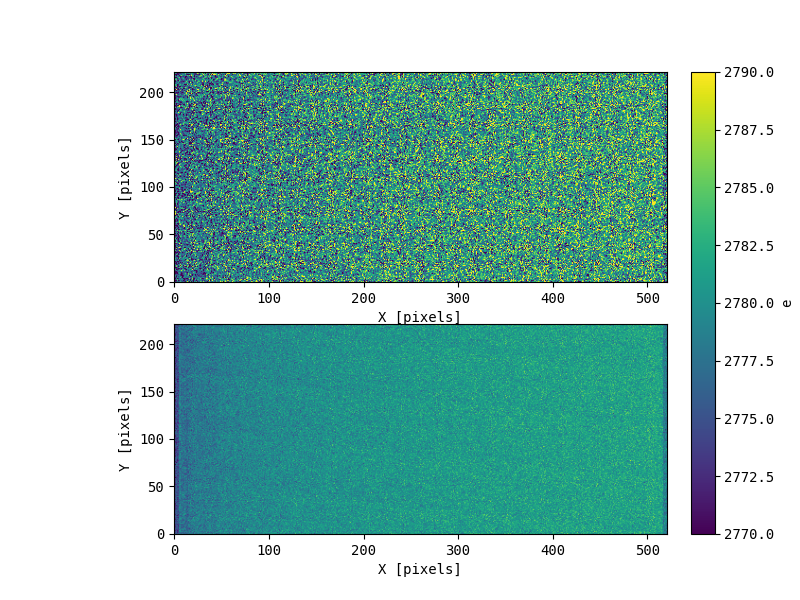

In [12]:
fig, ax = plt.subplots(2,1, figsize=(8,6)) # Caution, figsize will also influence positions.
im1 = ax[0].imshow(bias00_data, vmin = 2770, vmax =2790, origin='lower')
im2 = ax[1].imshow(median_bias, vmin = 2770, vmax =2790, origin='lower')
# add the colorbar using the figure's method,
# telling which mappable we're talking about and
# which axes object it should be near
cbar = fig.colorbar(im1, ax=ax, cmap='magma',fraction=0.046, pad=0.04)
cbar.set_label("e")
#ax[0].set_xlabel('X [pixels]')
ax[0].set_ylabel('Y [pixels]')
ax[1].set_xlabel('X [pixels]')
ax[1].set_ylabel('Y [pixels]')
plt.show()

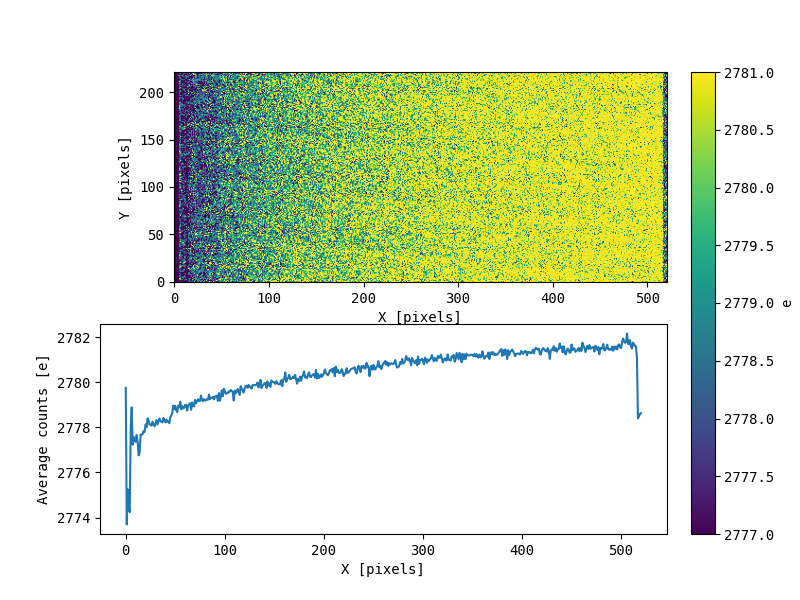

In [12]:
fig, ax = plt.subplots(2,1, figsize=(8,6)) # Caution, figsize will also influence positions.
im1 = ax[0].imshow(median_bias, vmin = 2777, vmax =2781, origin='lower')
median_column = np.average(median_bias, axis=0)
im2 = ax[1].plot(median_column)
# add the colorbar using the figure's method,
# telling which mappable we're talking about and
# which axes object it should be near
cbar = fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

cbar.set_label("e")
ax[0].set_xlabel('X [pixels]')
ax[0].set_ylabel('Y [pixels]')
ax[1].set_xlabel('X [pixels]')
ax[1].set_ylabel('Average counts [e]')
plt.show()

In [28]:
#  compare the readout noise as reported in the header of the fits frame 
# and the standard deviation directly computed of the data if we restrict 
# ourself to a small range in columns.

starting_column= 300
ending_column = 350
print('1) Readout noise : {0:4.2f} e'.format(bias00_readout_noise))
print('2) STD single frame : {0:4.2f} e'.format(np.std(bias00_data[:,starting_column:ending_column])))

1) Readout noise : 7.10 e
2) STD single frame : 7.49 e


In [27]:
expected_noise_medianbias = bias00_readout_noise/np.sqrt(n_images)
print('1) Expected noise of median bias : {0:4.2f} e'.format(expected_noise_medianbias))
expected_std_medianbias = np.std(bias00_data[:,starting_column:ending_column])/np.sqrt(n_images)
print('2) Expected STD of median bias : {0:4.2f} e'.format(expected_std_medianbias))

1) Expected noise of median bias : 1.30 e
2) Expected STD of median bias : 1.37 e


In [29]:
measured_std_medianbias = np.std(median_bias[:,starting_column:ending_column])
print('Measured STD of median bias : {0:4.2f} e'.format(measured_std_medianbias))
median_error = np.std(stack, axis=0) /np.sqrt(n_images) # saved in a file
median_pixel_error = np.median(median_error) # saved
print('Median STD of each pixel : {0:4.2f} e'.format(median_pixel_error))

Measured STD of median bias : 1.69 e
Median STD of each pixel : 1.31 e


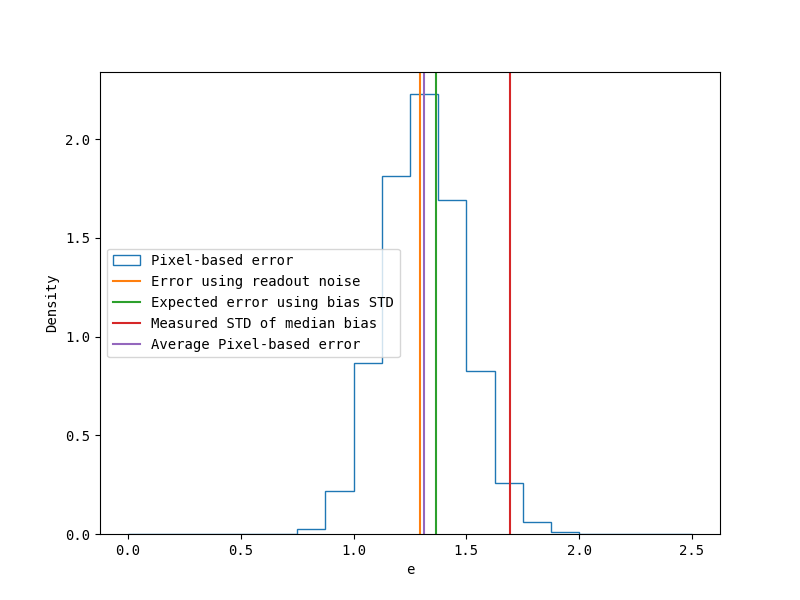

In [30]:
STD_pixel = np.std(stack, axis=0) 
plt.figure(figsize=(8,6))
plt.hist(median_error.flatten(), bins=20, range=(0,2.5), density=True,histtype='step', label='Pixel-based error')
plt.axvline(expected_noise_medianbias, c='C1', label='Error using readout noise')
plt.axvline(expected_std_medianbias, c='C2', label='Expected error using bias STD')
plt.axvline(measured_std_medianbias, c='C3', label='Measured STD of median bias')
plt.axvline(median_pixel_error, c='C4', label='Average Pixel-based error')
plt.xlabel('e')
plt.ylabel('Density')
plt.legend()
plt.show()

In [32]:
import pickle
# create a dictionary
pickle.dump(median_bias, open("median_bias.p","wb"))
pickle.dump(median_error, open("median_bias_error.p" ,"wb"))
pickle.dump(median_pixel_error, open("median_bias_error_value.p", "wb"))
pickle.dump(stack, open("stack_bias.p","wb"))